<a href="https://colab.research.google.com/github/pedrogebert-jpg/Alimentos_2026/blob/main/tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Beatriz Thainara, 17881120

Cristina Pan, 17884613

Pedro Musseli, 17919635

Grupo 4

Questões base de dados

4. Como se distribui o teor de proteína entre os alimentos? A distribuição apresenta concentração, dispersão ou algum comportamento que mereça atenção?
12. Qual alimento apresenta o maior teor de sódio e qual apresenta o menor? Além desses dois valores, que outras medidas poderiam ser utilizadas para descrever a amplitude e a dispersão dos dados?

Respostas:

4. Para responder à esta questão, faremos um gráfico com as informações do banco de dados fornecido:

In [3]:
import pandas as pd

# Carregar o arquivo Excel. Substitua 'caminho/para/seu/arquivo.xlsx' pelo caminho correto do seu arquivo.
df = pd.read_excel('/content/dadostarefa5.xlsx')

# Exibir as primeiras 5 linhas para verificar se o carregamento foi bem-sucedido
display(df.head())

,ID,Alimento,Categoria,Proteína (g),Gordura total (g),Sódio (mg),fdc_id
0,1,"Rúcula, baby, crua",Vegetais e Produtos Vegetais,1.648750,0.3250,86.93,2710822
1,2,"Aspargos verdes, crus",Vegetais e Produtos Vegetais,1.437500,0.2163,2.46,2710823
2,3,"Vagem, enlatada, embalagem comum, escorrida",Vegetais e Produtos Vegetais,1.040000,0.3900,282.00,321611
3,4,"Vagem, crua",Vegetais e Produtos Vegetais,1.968750,0.2750,0.00,2346400
4,5,"Folhas de beterraba, cruas",Vegetais e Produtos Vegetais,1.609375,0.1438,280.50,2747653


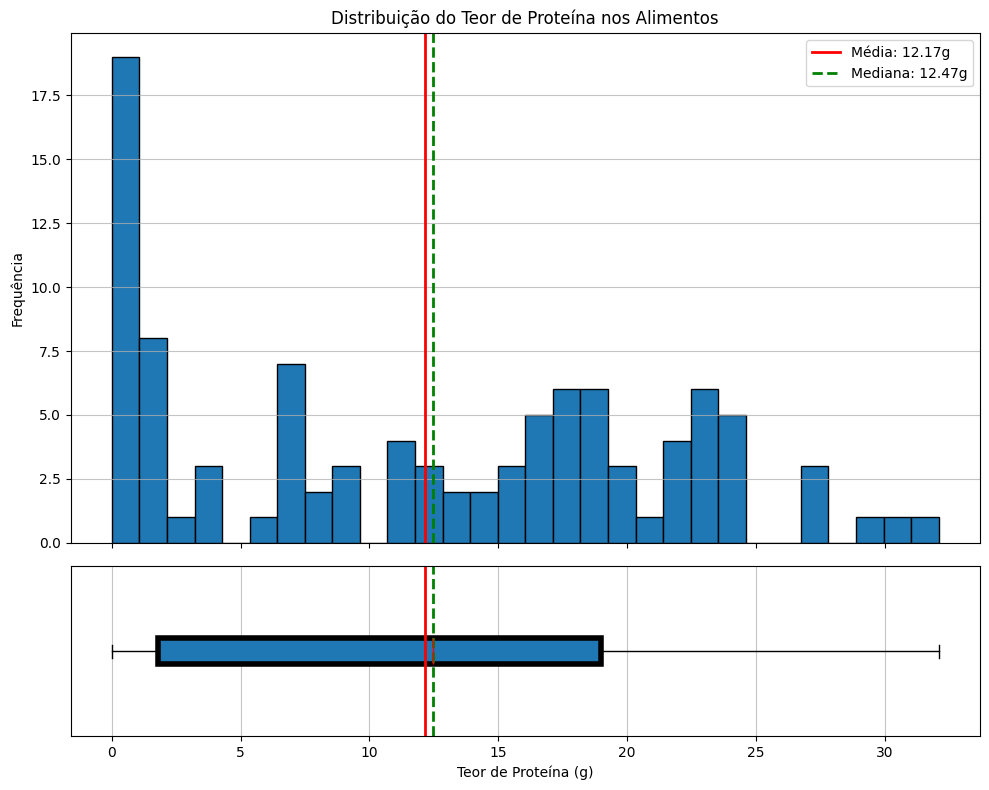

In [7]:
import matplotlib.pyplot as plt

protein_column = 'Proteína (g)' # Replace with the actual column name for protein if different

if protein_column in df.columns:
    # Clean data for calculations and plotting
    protein_data = df[protein_column].dropna()

    # Create subplots for histogram and boxplot, sharing the x-axis
    fig, (ax_hist, ax_box) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Calculate mean and median
    mean_protein = protein_data.mean()
    median_protein = protein_data.median()

    # Plot histogram on the top subplot
    ax_hist.hist(protein_data, bins=30, edgecolor='black')
    ax_hist.set_title('Distribuição do Teor de Proteína nos Alimentos')
    ax_hist.set_ylabel('Frequência')
    ax_hist.grid(axis='y', alpha=0.75)

    # Add mean and median lines to the histogram
    ax_hist.axvline(mean_protein, color='red', linestyle='-', linewidth=2, label=f'Média: {mean_protein:.2f}g')
    ax_hist.axvline(median_protein, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_protein:.2f}g')
    ax_hist.legend()

    # Plot boxplot on the bottom subplot
    # Make outliers more visible by customizing flierprops
    flierprops = dict(markerfacecolor='purple', marker='o', markersize=8, markeredgecolor='black', alpha=0.7)
    ax_box.boxplot(protein_data, vert=False, patch_artist=True, medianprops={'color': 'red'}, boxprops={'linewidth': 4, 'edgecolor': 'black'}, flierprops=flierprops)
    ax_box.set_xlabel('Teor de Proteína (g)')
    ax_box.set_yticks([]) # Hide y-axis ticks for the boxplot
    ax_box.grid(axis='x', alpha=0.75)

    # Add mean and median lines to the boxplot as well
    ax_box.axvline(mean_protein, color='red', linestyle='-', linewidth=2)
    ax_box.axvline(median_protein, color='green', linestyle='--', linewidth=2)

    plt.tight_layout() # Adjust layout to prevent overlapping elements
    plt.show()
else:
    print(f"Column '{protein_column}' not found in the DataFrame. Please check the column name from the previous output and update it.")

O teor de proteínas apresenta uma distribuição bastante dispersa. Há uma concentração maior de alimentos com baixo a moderado teor de proteína, especialmente na faixa de aproximadamente 2-20g. A distribuição não é perfeitamente simétrica, embora não podemos classificá-la como assimétrica (pelo fato das linhas de média e medianas estarem muito próximas). Podemos observar uma espécie de cauda para a direita formada pelos alimentos com maior teor de proteína.

12. O alimento que possui a maior taxa de sódio é a anchova enlatada em azeite de oliva. Já o alimento que possui menor teor de sódio são, por exemplo, as vagens cruas, já que mais de um alimento possui 0mg. Além desses dois valores, o desvio padrão,a variância e o intervalo interquartil (IQR) também podem ser utilizados para analisar a amplitude e a dispersão de dados.